<span style='font-size:40px; display:block;'>
<b>
    FLUXES
</b>
</span>

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# **Imports**

In [1]:
import importlib.metadata
import warnings
from datetime import datetime
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.heatmap_datetime import HeatmapDateTime, HeatmapYearMonth

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.86.0


# **Load data**

In [2]:
SOURCEDIR = r"../70_FINAL_MERGE"
FILENAME = r"71.1_FLUXES_METEO_MGMT_L4.1_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)
df

Loaded .parquet file ..\70_FINAL_MERGE\71.1_FLUXES_METEO_MGMT_L4.1_NEE_LE_H_FN2O_FCH4_REDDYPROC.parquet (0.365 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,AIR_CP,AIR_DENSITY,AIR_MV,AIR_RHO_CP,AOA_METHOD,AXES_ROTATION_METHOD,BADM_HEIGHTC,BADM_INSTPAIR_EASTWARD_SEP_GA_CH4,BADM_INSTPAIR_EASTWARD_SEP_GA_CO2,BADM_INSTPAIR_EASTWARD_SEP_GA_H2O,BADM_INSTPAIR_EASTWARD_SEP_GA_N2O,BADM_INSTPAIR_HEIGHT_SEP_GA_CH4,BADM_INSTPAIR_HEIGHT_SEP_GA_CO2,BADM_INSTPAIR_HEIGHT_SEP_GA_H2O,BADM_INSTPAIR_HEIGHT_SEP_GA_N2O,...,FLAG_FCH4_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED,NEE_U16_f_reddyproc,Reco_U16_reddyproc,GPP_U16_f_reddyproc,NEE_U50_f_reddyproc,Reco_U50_reddyproc,GPP_U50_f_reddyproc,NEE_U84_f_reddyproc,Reco_U84_reddyproc,GPP_U84_f_reddyproc,LE_f_reddyproc,H_f_reddyproc,ET_f_reddyproc
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-12-31 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.465083,1.471708,0.006625,1.531928,1.515735,-0.016194,1.584801,1.552012,-0.032789,1.313335,1.188433,0.029150
2020-12-31 23:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.465083,1.470454,0.005372,1.531928,1.514467,-0.017462,1.584801,1.550737,-0.034063,1.301519,2.905173,0.028888
2021-01-01 00:15:00,1008.65,1.20907,0.023898,1219.53,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-17.0,-17.0,NaN,...,NaN,NaN,NaN,1.465083,1.470235,0.005152,1.531928,1.514245,-0.017684,1.584801,1.550514,-0.034287,0.055464,-3.557021,0.001231
2021-01-01 00:45:00,1008.64,1.20915,0.023896,1219.60,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-17.0,-17.0,NaN,...,NaN,NaN,NaN,1.465083,1.471799,0.006717,1.531928,1.515828,-0.016101,1.584801,1.552106,-0.032695,0.348332,-3.557021,0.007731
2021-01-01 01:15:00,1008.64,1.20925,0.023894,1219.70,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-17.0,-17.0,NaN,...,NaN,NaN,NaN,1.465083,1.473942,0.008859,1.531928,1.517995,-0.013933,1.584801,1.554285,-0.030515,-0.038865,-3.557021,-0.000863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 21:45:00,1008.89,1.21242,0.023828,1223.20,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-16.0,-16.0,NaN,...,NaN,NaN,NaN,1.432823,1.615999,0.183175,1.370211,1.626682,0.256471,1.348048,1.636257,0.288208,-0.853410,-5.293847,-0.018971
2023-12-31 22:15:00,1008.98,1.21206,0.023834,1222.94,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-16.0,-16.0,NaN,...,NaN,NaN,NaN,0.593252,1.674743,1.081492,0.593252,1.684758,1.091506,0.593252,1.693603,1.100351,-1.187178,-3.587753,-0.026404
2023-12-31 22:45:00,1009.08,1.21061,0.023861,1221.60,0.0,1.0,0.5,NaN,-2.5,-2.5,NaN,NaN,-16.0,-16.0,NaN,...,NaN,NaN,NaN,1.295956,1.747225,0.451269,1.295956,1.756364,0.460408,1.295956,1.764261,0.468305,-0.409499,-6.293662,-0.009113


# **List of gap-filled flux variables**

In [3]:
fluxlist = [c for c in df.columns if str(c).endswith("gfRF")];
fluxlist

['NEE_L3.1_L3.3_CUT_16_QCF_gfRF',
 'NEE_L3.1_L3.3_CUT_50_QCF_gfRF',
 'NEE_L3.1_L3.3_CUT_84_QCF_gfRF',
 'LE_L3.1_L3.3_CUT_NONE_QCF_gfRF',
 'H_L3.1_L3.3_CUT_NONE_QCF_gfRF',
 'FN2O_L3.1_L3.3_CUT_16_QCF_gfRF',
 'FN2O_L3.1_L3.3_CUT_50_QCF_gfRF',
 'FN2O_L3.1_L3.3_CUT_84_QCF_gfRF',
 'FCH4_L3.1_L3.3_CUT_16_QCF_gfRF',
 'FCH4_L3.1_L3.3_CUT_50_QCF_gfRF',
 'FCH4_L3.1_L3.3_CUT_84_QCF_gfRF']

# **Fluxes: gap-filled** (random forest)

## Main ecosystem fluxes

In [4]:
nee = 'NEE_L3.1_L3.3_CUT_50_QCF_gfRF'
le = 'LE_L3.1_L3.3_CUT_NONE_QCF_gfRF'
h = 'H_L3.1_L3.3_CUT_NONE_QCF_gfRF'
n2o = 'FN2O_L3.1_L3.3_CUT_50_QCF_gfRF'
ch4 = 'FCH4_L3.1_L3.3_CUT_50_QCF_gfRF'
fluxes = [nee, le, h, n2o, ch4]
fluxes

['NEE_L3.1_L3.3_CUT_50_QCF_gfRF',
 'LE_L3.1_L3.3_CUT_NONE_QCF_gfRF',
 'H_L3.1_L3.3_CUT_NONE_QCF_gfRF',
 'FN2O_L3.1_L3.3_CUT_50_QCF_gfRF',
 'FCH4_L3.1_L3.3_CUT_50_QCF_gfRF']

## Heatmaps (half-hourly fluxes)

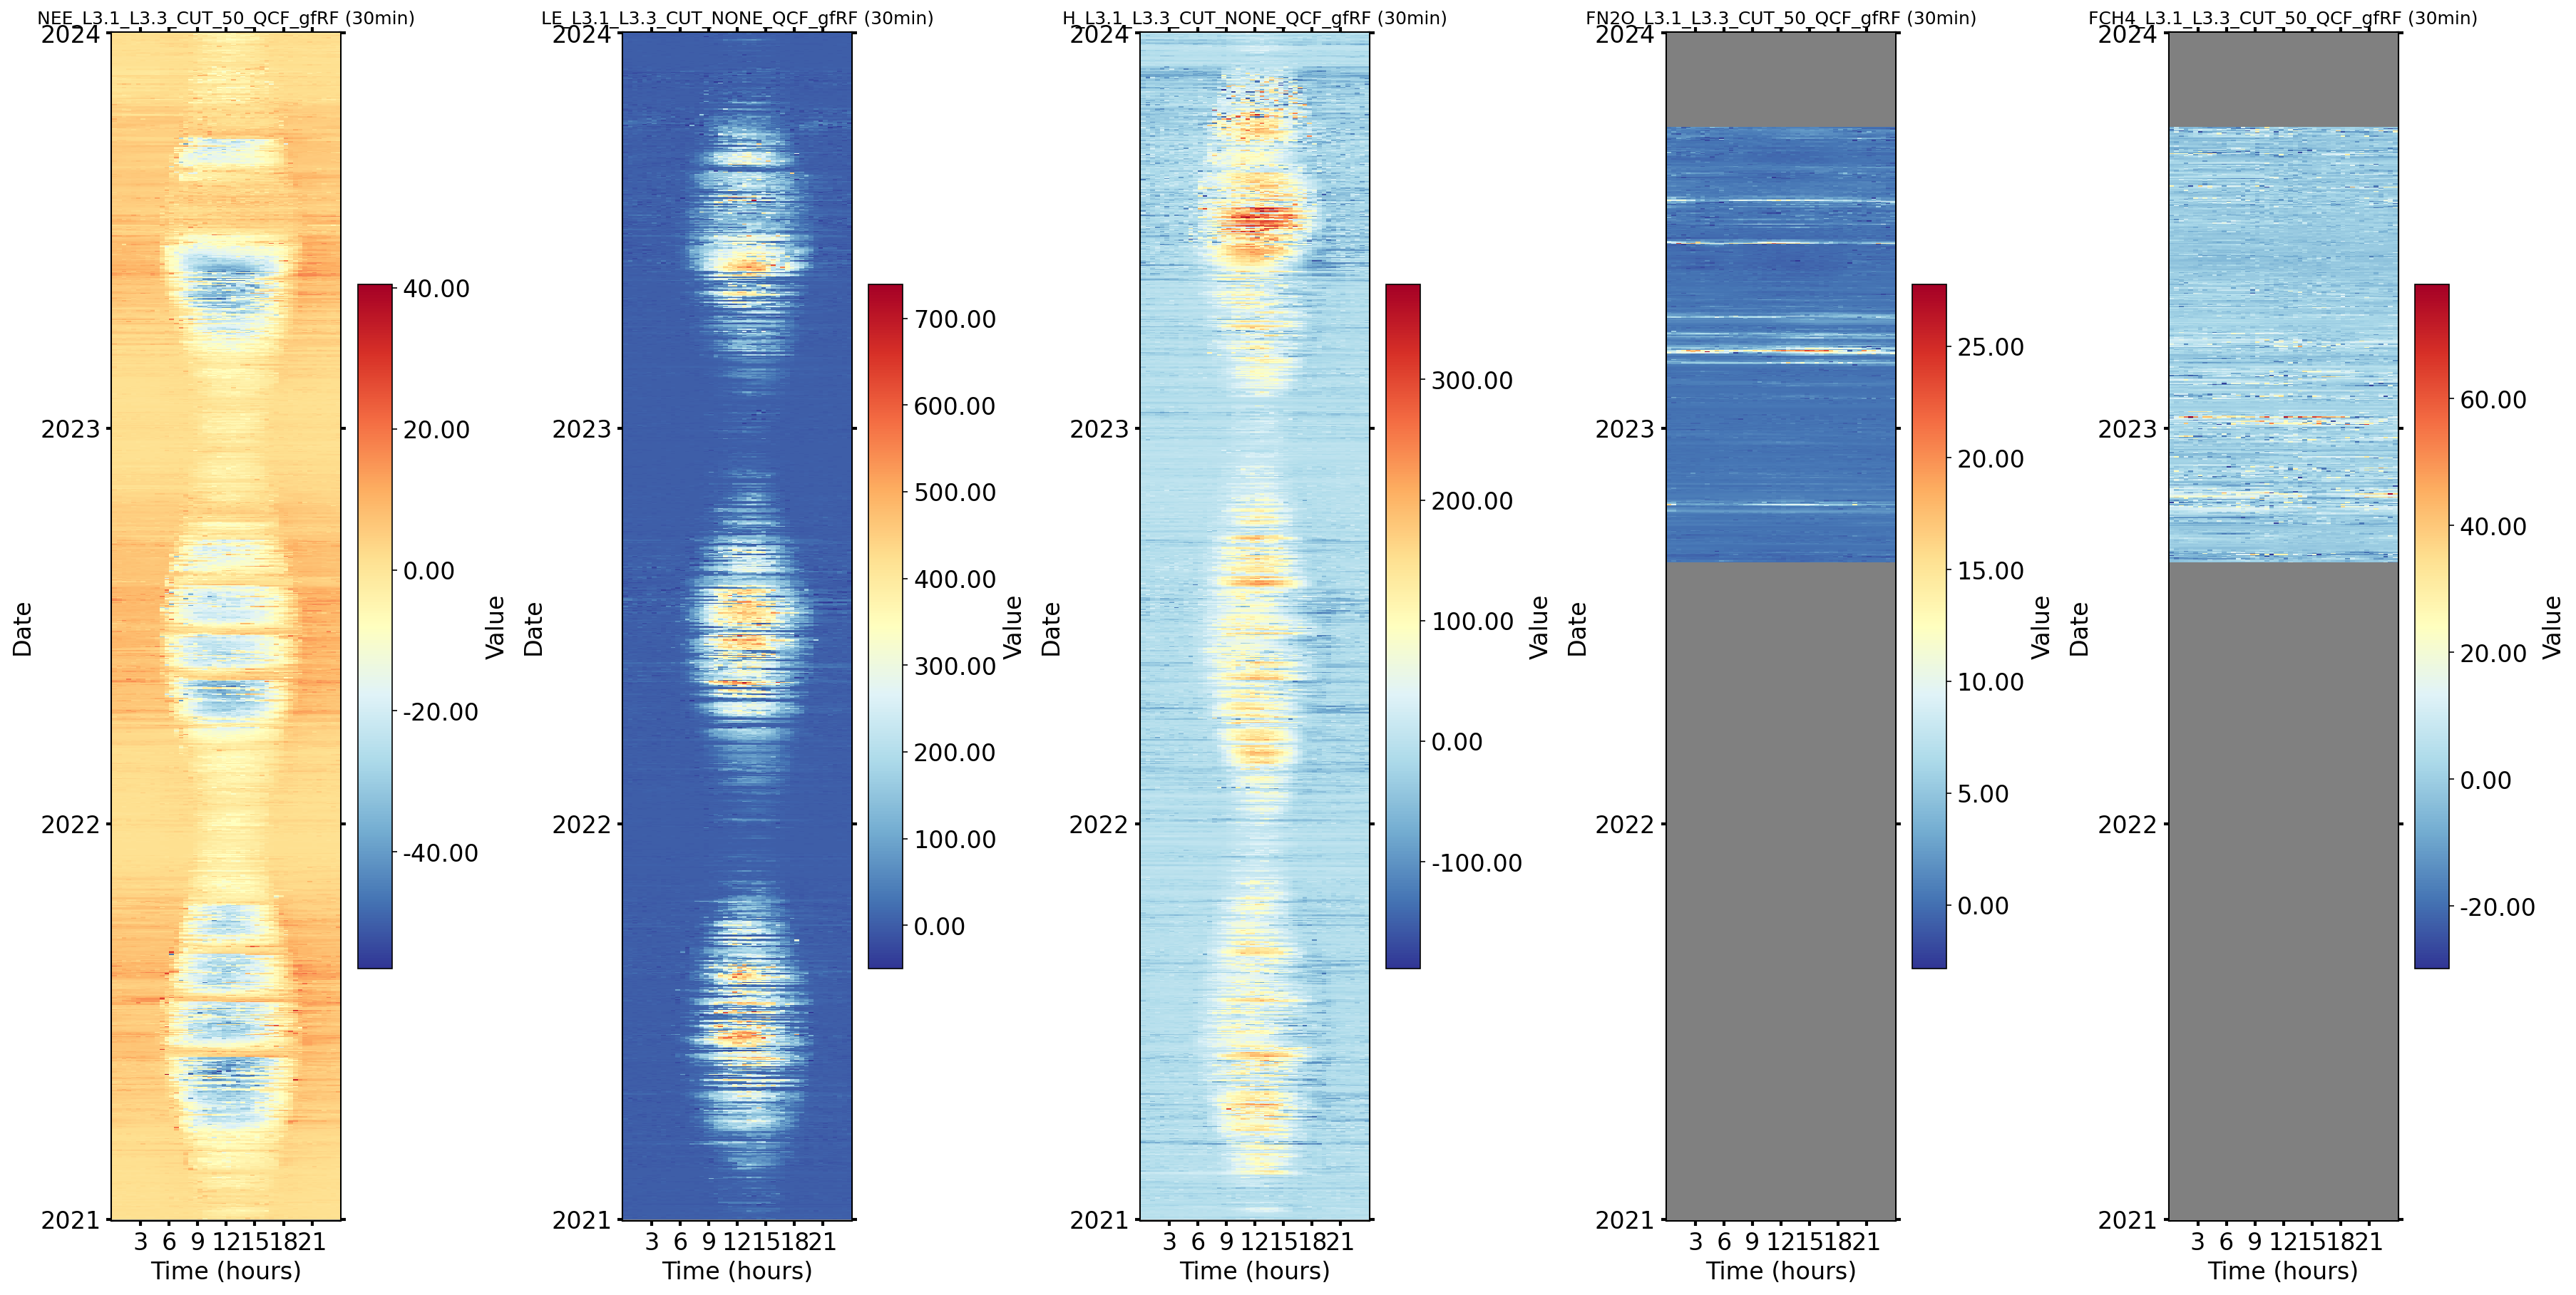

In [5]:
fig, axs = plt.subplots(ncols=5, figsize=(24, 12), dpi=150, layout="constrained")
HeatmapDateTime(series=df[nee], ax=axs[0]).plot()
HeatmapDateTime(series=df[le], ax=axs[1]).plot()
HeatmapDateTime(series=df[h], ax=axs[2]).plot()
HeatmapDateTime(series=df[n2o], ax=axs[3]).plot()
HeatmapDateTime(series=df[ch4], ax=axs[4]).plot()

## Heatmaps (monthly fluxes)

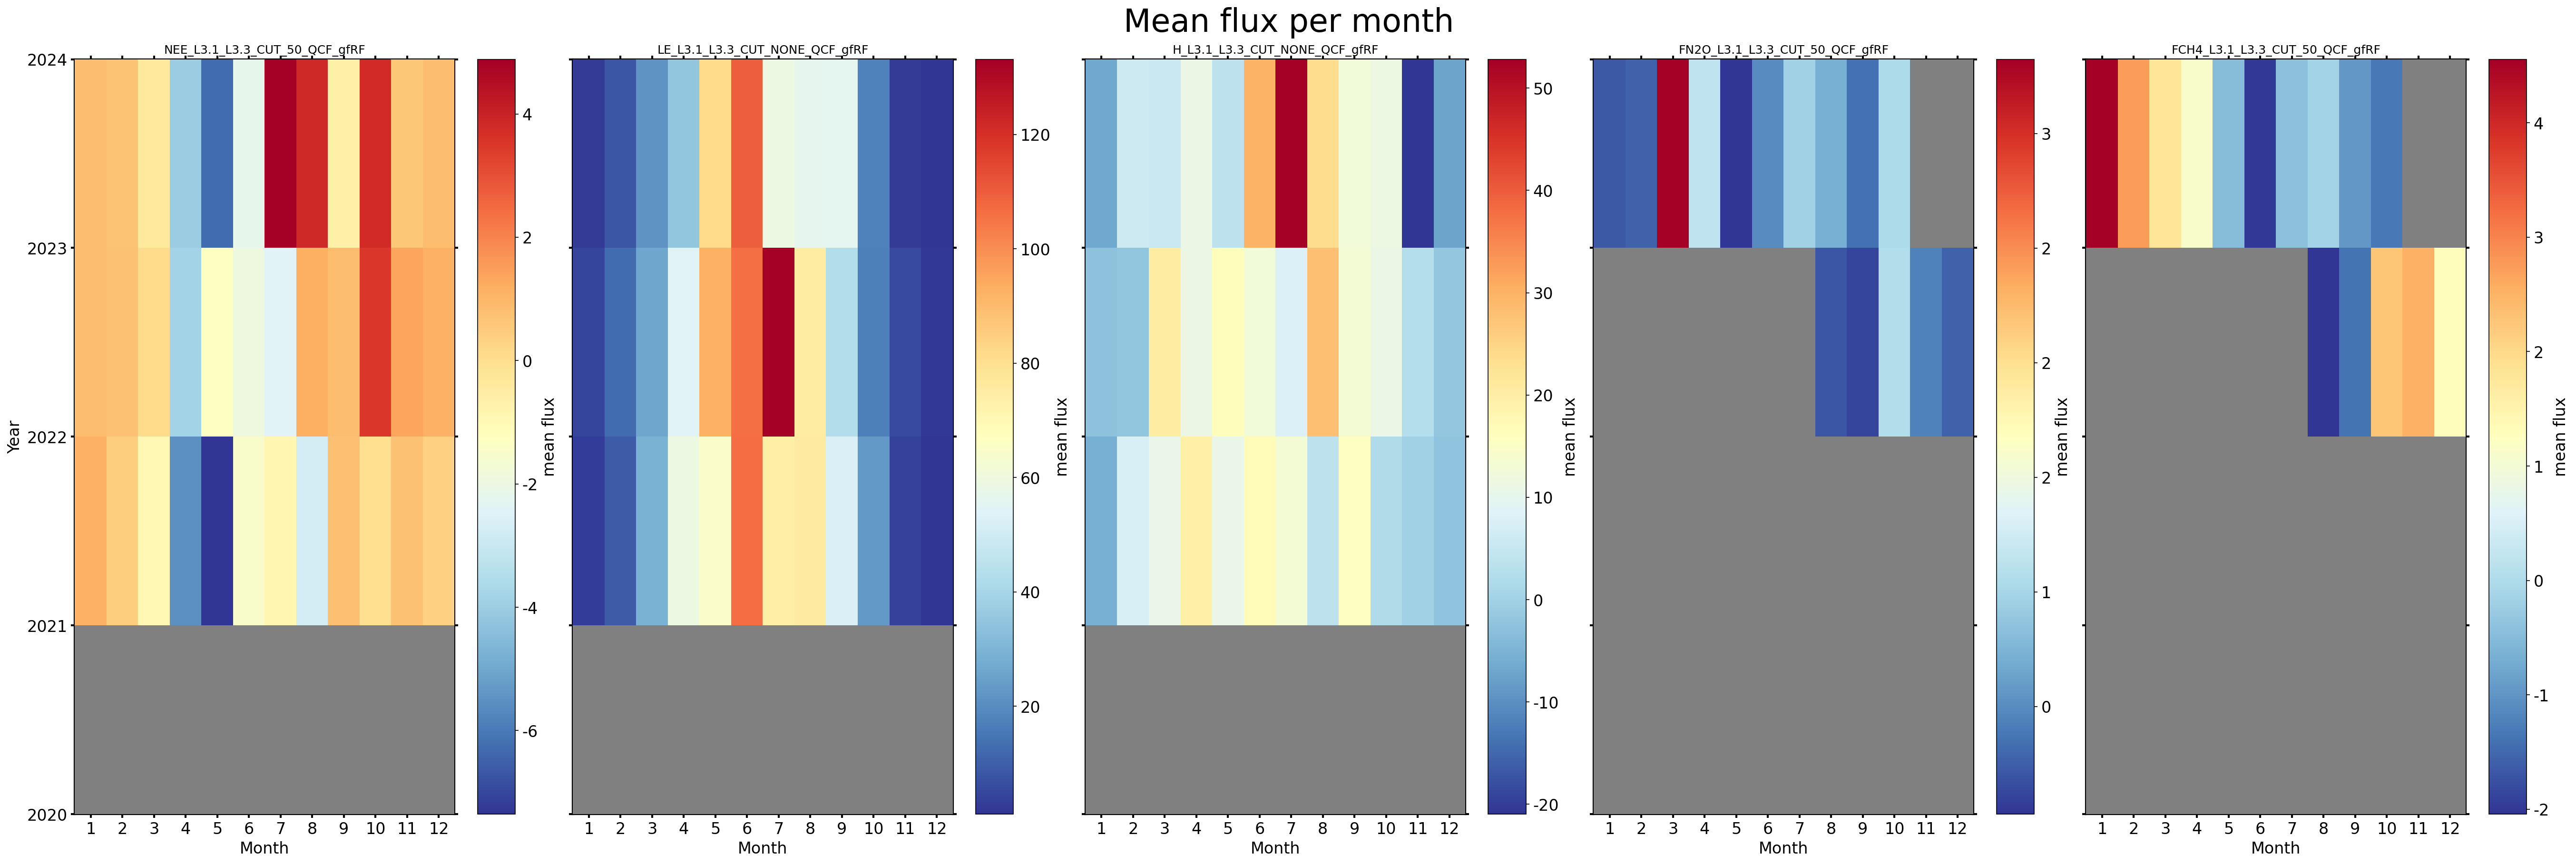

In [6]:
fig, axs = plt.subplots(ncols=5, figsize=(36, 12), dpi=150, layout="constrained")
fig.suptitle(f'Mean flux per month', fontsize=32)

for ix, f in enumerate(fluxes):
    s = df[f].resample('M').mean()        
    HeatmapYearMonth(series_monthly=s, title=s.name, ax=axs[ix], cb_digits_after_comma=0, zlabel="mean flux").plot()

# axs[0].axes.get_yaxis().get_label().set_visible(False)
hide_labels = [1, 2, 3, 4]
for h in hide_labels:
    axs[h].axes.get_yaxis().get_label().set_visible(False)
    plt.setp(axs[h].get_yticklabels(), visible=False)

## Cumulatives per year

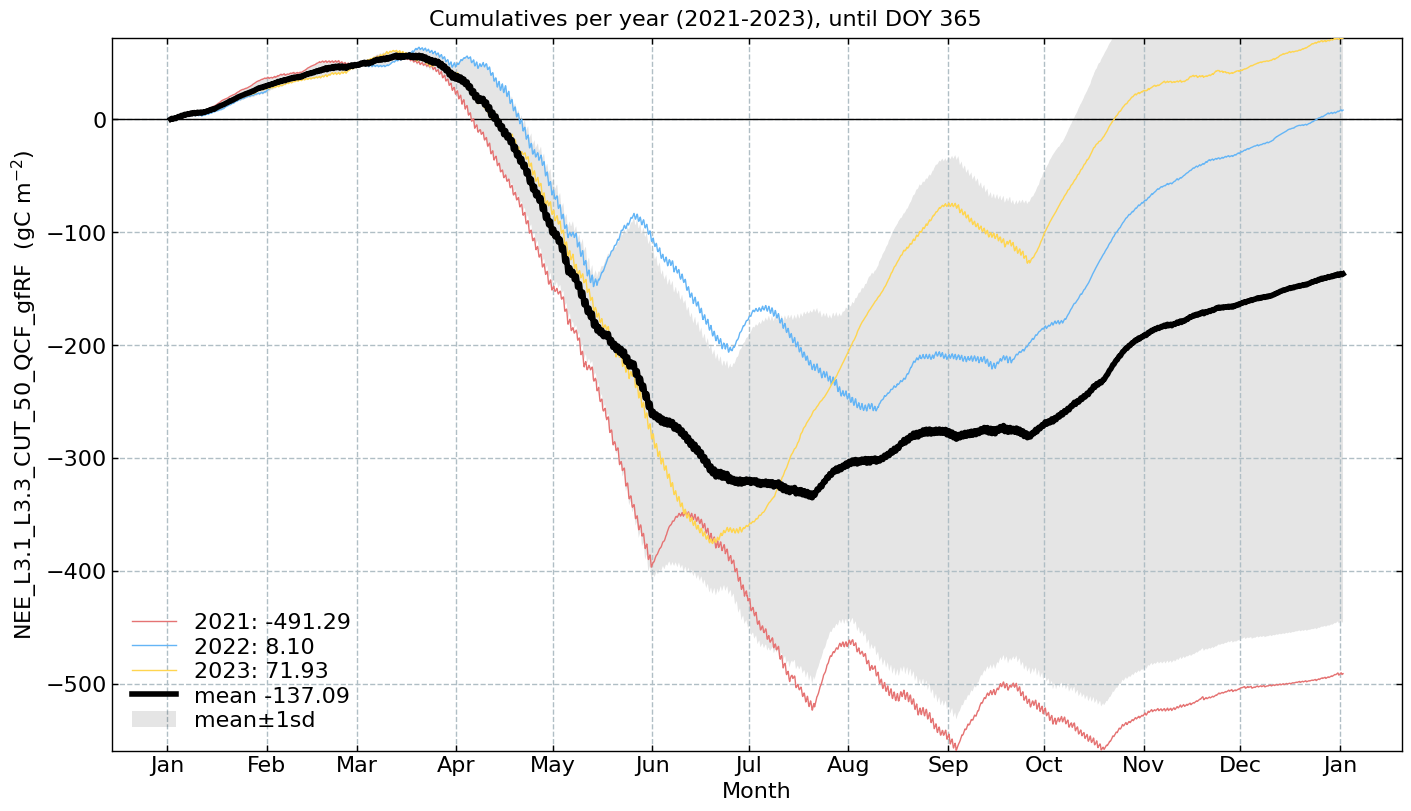

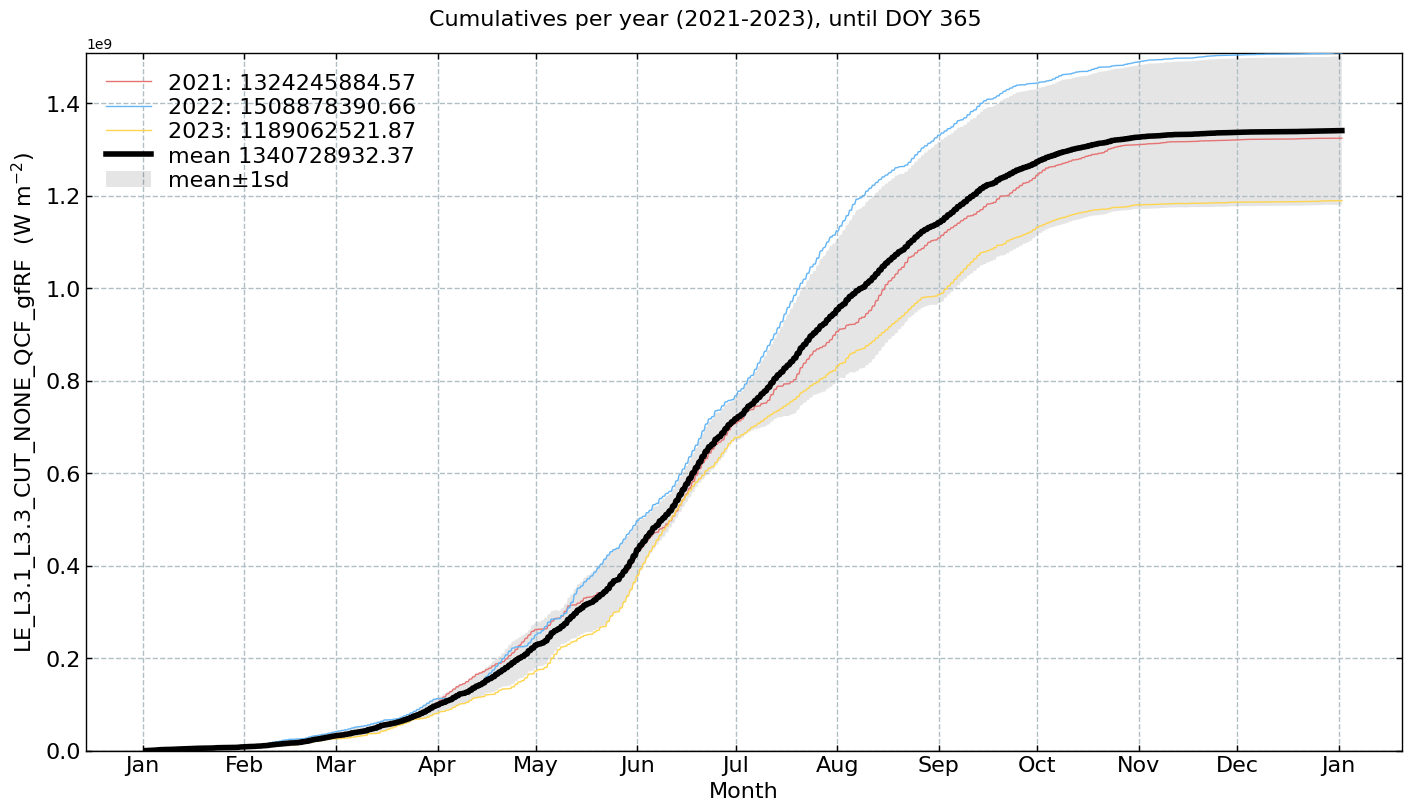

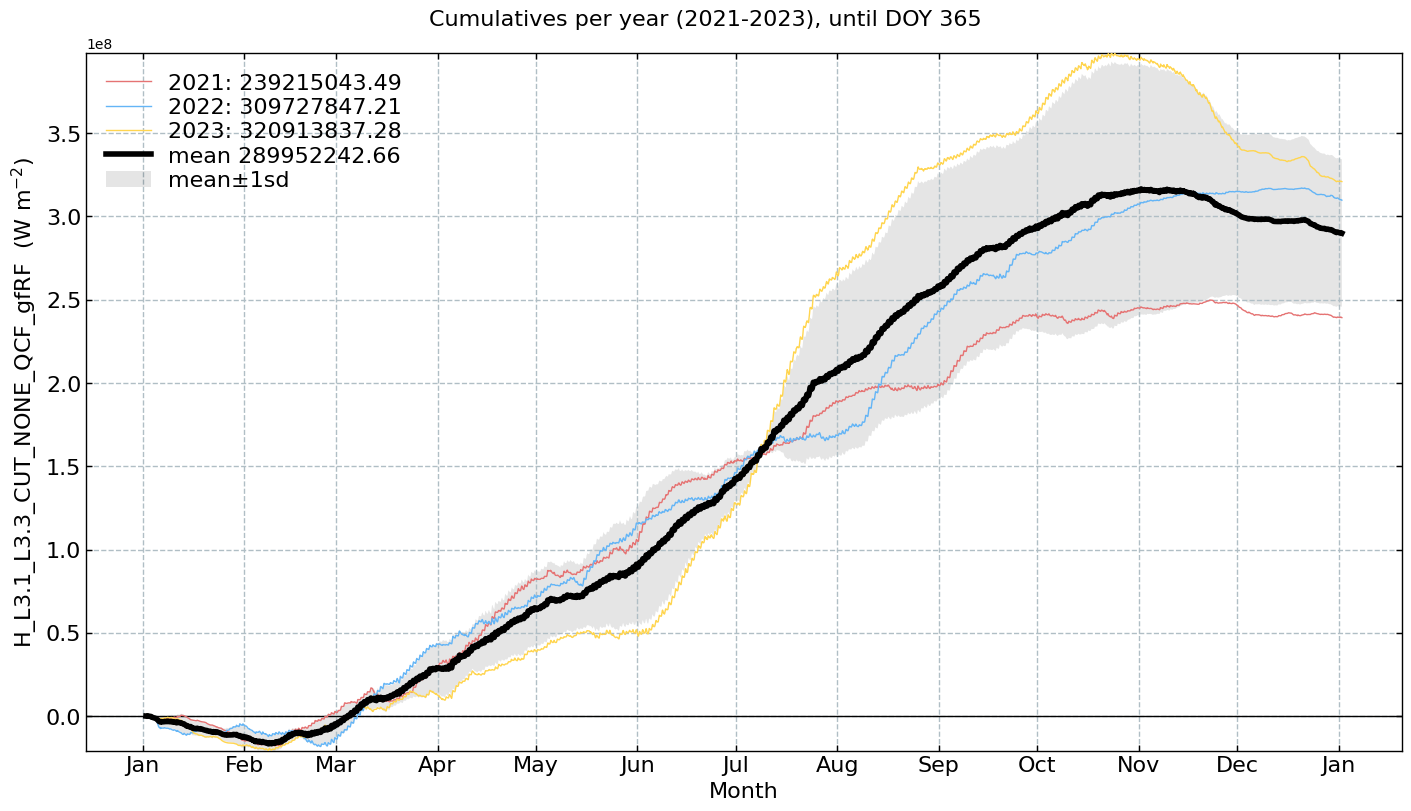

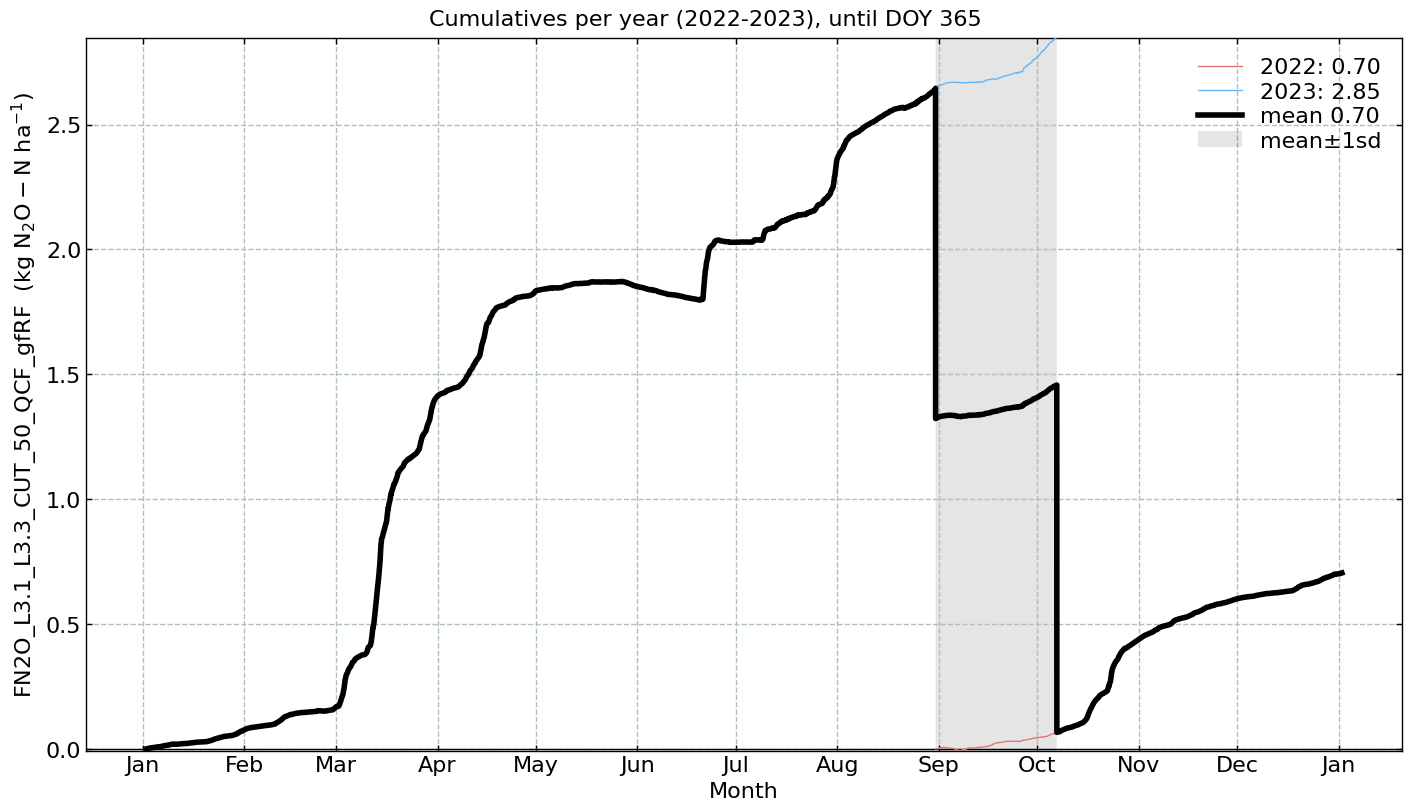

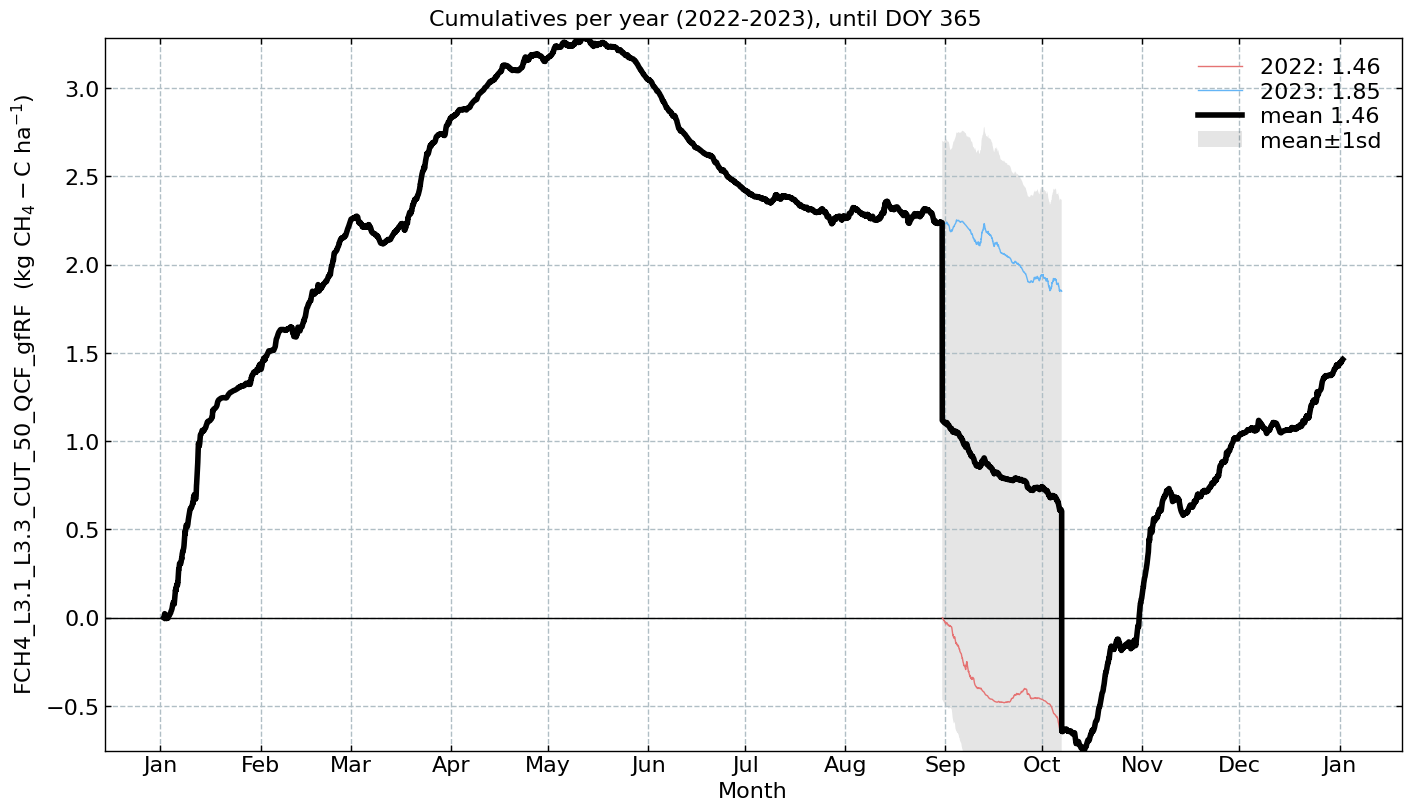

In [7]:
# Conversion factors and resulting units
conversions = {
    'NEE_L3.1_L3.3_CUT_50_QCF_gfRF': [0.02161926, r'($\mathrm{gC\ m^{-2}}$)'],  # umol CO2 m-2 s-1 --> gC m-2 yr-1
    'LE_L3.1_L3.3_CUT_NONE_QCF_gfRF': [1800, r'($\mathrm{W\ m^{-2}}$)'],  # W m-2 s-1 --> W m-2 yr-1
    'H_L3.1_L3.3_CUT_NONE_QCF_gfRF': [1800, r'($\mathrm{W\ m^{-2}}$)'],  # W m-2 s-1 --> W m-2 yr-1
    'FN2O_L3.1_L3.3_CUT_50_QCF_gfRF': [0.0002521206, r'($\mathrm{kg\ N_2O-N\ ha^{-1}}$)'],  # nmol N2O m-2 s-1 --> kg N2O-N ha-1 yr-1
    'FCH4_L3.1_L3.3_CUT_50_QCF_gfRF': [0.000216198, r'($\mathrm{kg\ CH_4-C\ ha^{-1}}$)']  # nmol CH4 m-2 s-1 --> kg CH4-C ha-1 yr-1
}

for f in fluxes:
    s = df[f].multiply(conversions[f][0])
    units = conversions[f][1]

    CumulativeYear(
        series=s,
        series_units=units,
        start_year=2005,
        end_year=2024,
        show_reference=True,
        excl_years_from_reference=None,
        highlight_year=None,
        highlight_year_color='#F44336').plot();

# **End of notebook**

In [8]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-07-30 17:20:06
